**Redes Neuronales Convolucionales (CNN) en Imágenes Médicas**

Una **Red Neuronal Convolucional (CNN)** es un tipo de arquitectura de aprendizaje profundo diseñada específicamente para procesar datos con **estructura espacial**, siendo las imágenes el ejemplo principal.

A diferencia de las redes tradicionales, las CNN aprovechan la **correlación local** de los píxeles (bordes, texturas y formas) mediante el uso de **convoluciones**: filtros aprendibles que se deslizan sobre la imagen para extraer patrones de manera automática.

 Componentes Clave de una CNN

Las CNN procesan la información a través de una secuencia de capas especializadas:

* **Convolución (`Conv2D`):** Aplica filtros (*kernels*) numéricos para generar mapas de características. En las capas iniciales detecta bordes y texturas; en las capas profundas reconoce estructuras complejas.
* **Activación (`ReLU`):** Introduce no linealidad en el modelo mediante la función \(ReLU(x) = \max(0, x)\), permitiendo que la red aprenda patrones complejos y se entrene más rápido.
* **Reducción (`MaxPool`):** Reduce la resolución espacial de los mapas de características quedándose solo con el valor máximo. Esto disminuye el costo computacional y ayuda a evitar el sobreajuste (*overfitting*).
* **Capas Densas (`Fully-Connected`):** Se ubican al final de la red. Aplanan las características extraídas y las integran completamente para realizar la clasificación o regresión final.


 ¿Por qué se usan en Imágenes Médicas?

El uso de CNNs ha revolucionado el análisis de imágenes clínicas (como radiografías, tomografías y resonancias) por tres razones principales:

1. **Detección de patrones sutiles:** Identifican anomalías críticas que pueden ser difíciles de ver a simple vista, como opacidades, consolidaciones o cambios mínimos de textura.
2. **Aprendizaje jerárquico:** Eliminan la necesidad de realizar ingeniería manual de características, ya que la red aprende por sí misma qué elementos visuales son clínicamente relevantes.
3. **Aprendizaje por transferencia (*Transfer Learning*):** Permiten reutilizar modelos preentrenados en grandes datasets comerciales (como ImageNet) para lograr una alta precisión médica, incluso cuando se dispone de pocos datos de pacientes.


1. **Instalación de dependencias e importación de librerías** :

En este paso instalamos la librería oficial de MedMNIST e importamos las dependencias fundamentales para la manipulación de datos, creación de tensores y visualización.

In [54]:
# Instalación del paquete MedMNIST
!pip install -q medmnist

# Librerías esenciales de Python y PyTorch
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Módulo principal de MedMNIST y su diccionario de metadatos
import medmnist
from medmnist import INFO

2. **Configuración del dispositivo de cómputo (GPU / CPU)**:

Se verifica si hay una GPU aceleradora disponible (CUDA) para procesar los datos de manera más rápida; de lo contrario, se usa la CPU.

In [55]:
# Selección automática de aceleración gráfica si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device}")

Dispositivo en uso: cpu


3. **Carga y binarización del dataset RetinaMNIST (Etiquetas 0 y 1)**:

En este paso descargamos las particiones oficiales de RetinaMNIST y transformamos inmediatamente sus etiquetas originales (grados 0, 1, 2, 3, 4) en únicamente dos clases: 0 (Sin retinopatía / Sano) y 1 (Con retinopatía / Enfermo).

In [108]:
# Paso 3 corregido para RetinaMNIST
data_flag = "retinamnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

# Transformación de imágenes
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])  # RetinaMNIST suele ser escala de grises/1 canal en MedMNIST 28x28
])

# Carga de particiones
train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset   = DataClass(split="val",   transform=transform, download=True)
test_dataset  = DataClass(split="test",  transform=transform, download=True)

# Binarización del dataset: Grado 0 -> 0 (Sin Retinopatía), Grados 1, 2, 3, 4 -> 1 (Con Retinopatía)
train_dataset.labels = (train_dataset.labels.squeeze() > 0).astype(int)
val_dataset.labels   = (val_dataset.labels.squeeze() > 0).astype(int)
test_dataset.labels  = (test_dataset.labels.squeeze() > 0).astype(int)

4. 4: **Creación de los DataLoaders de PyTorch**:

Agrupamos los datos binarizados en lotes (batches) para alimentar el modelo en el entrenamiento.

In [70]:
from torch.utils.data import DataLoader

# Creación de DataLoaders para entrenamiento, validación y prueba
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Extraer un lote para verificar la forma (shape) y el tipo de dato
sample_images, sample_labels = next(iter(train_loader))

# Muestra de control
print("Imágenes (train):", sample_images.shape)
print("Etiquetas (train):", sample_labels.shape, "| Tipo:", sample_labels.dtype)

Imágenes (train): torch.Size([128, 1, 28, 28])
Etiquetas (train): torch.Size([128]) | Tipo: torch.int64


5. **Visualización de muestras binarias**:

Desplegamos una retícula de imágenes confirmando que la clasificación asignada ahora corresponde exclusivamente a 0: Sin Retinopatía o 1: Con Retinopatía.

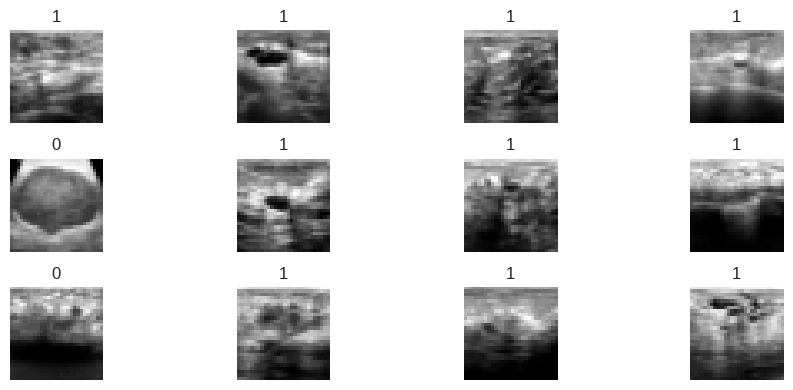

In [58]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

6. **Definición de la Red Neuronal Convolucional (CNN)**:

Construimos una arquitectura de red convolucional adaptada para imágenes de $1$ canal (escala de grises) y tamaño de $28 \times 28$ píxeles.

In [59]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    # --- AGREGAR ESTAS LÍNEAS QUE FALTABAN ---
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [60]:
num_classes = 2
model_scratch = SimpleCNN(num_classes=num_classes).to(device)
optimizer = torch.optim.AdamW(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)

7. **Definición de la Función de Pérdida (Loss) y el Optimizador**:

Una vez definido el modelo, se debe establecer cómo medirá sus errores y cómo actualizará sus pesos

In [61]:
import torch.optim as optim

# 1. Función de pérdida para clasificación multiclase / binaria con salida de 2 clases
criterion = nn.CrossEntropyLoss()

# 2. Optimizador Adam para actualizar los pesos de la red
optimizer = optim.Adam(model_scratch.parameters(), lr=0.001)

7,1.  **Funciones de entrenamiento y evaluación**:


Definimos las dos funciones principales del ciclo de aprendizaje: train_epoch para actualizar los pesos del modelo procesando el conjunto de entrenamiento, y evaluate para medir la precisión y pérdida en los conjuntos de validación o prueba sin modificar la red.

In [62]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# 1. Función para convertir logits en probabilidades de la clase positiva (1)
def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:, 1]  # Extrae la probabilidad de la clase 1

# 2. Función principal de evaluación
@torch.no_grad()
def evaluate(model, loader):
    model.eval()  # Activa el modo de evaluación (desactiva Dropout)
    all_labels, all_probs, all_preds = [], [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)  # Asegura vector unidimensional de etiquetas

        # Paso hacia adelante (Forward)
        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()     # Umbral de decisión en 0.5 (Clase 0 o 1)

        # Almacenar resultados del lote pasándolos a CPU y formato NumPy
        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    # Concatenar todos los lotes en un solo vector continuo
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    # Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)  # Métrica binaria mediante probabilidades continuas

    return acc, auc, y_true, y_pred, y_prob

7.2. Entrenar el modelo desde cero:

A continuación se presenta la celda completa de entrenamiento configurada con el planificador de tasa de aprendizaje (Scheduler), regularización AdamW y cálculo explícito de diferencias entre métricas para controlar el sobreajuste (overfitting).

In [87]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Balanceo de clases para evitar que el modelo prediga solo la clase mayoritaria
labels_train = train_dataset.labels
class_counts = np.bincount(labels_train)
total_samples = len(labels_train)

# Pesos inversamente proporcionales a la frecuencia de cada clase
class_weights = torch.tensor([
    total_samples / (2.0 * class_counts[0]),
    total_samples / (2.0 * class_counts[1])
], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# 2. Optimizador y Scheduler de Tasa de Aprendizaje
optimizer = optim.AdamW(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# 3. Función de entrenamiento por época
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)

# 4. Creación de DataLoader para validación y prueba
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 5. Bucle principal de entrenamiento
num_epochs = 15

print("--- Inicio del Entrenamiento ---")
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model_scratch, train_loader, criterion, optimizer)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    # Ajustar la tasa de aprendizaje según la mejora del AUC en validación
    scheduler.step(val_auc)

    print(f"Época [{epoch:02d}/{num_epochs:02d}] | Loss Entrenar: {train_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val AUC: {val_auc:.4f}")



ValueError: object too deep for desired array

In [90]:
import numpy as np
import torch
import torch.nn as nn

# Reinicia el modelo desde cero para que la comparación sea justa
model_scratch = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_scratch.parameters(), lr=5e-4, weight_decay=1e-4)

epochs = 20
# El LR baja suavemente de 5e-4 hasta casi 0 a lo largo de las 15 épocas
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

history_scratch = {
    "train_loss": [], "val_loss": [],
    "train_acc": [],  "val_acc": [],
    "diff_loss": [],  "diff_acc": []
}

@torch.no_grad()
def compute_loss(model, loader):
    model.eval()
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device).long().view(-1)
        loss = criterion(model(x), y)
        losses.append(loss.item())
    return float(np.mean(losses))

print(f"{'Época':^7} | {'Train Loss':^10} | {'Val Loss':^10} | {'Dif Loss':^10} | {'Train Acc':^10} | {'Val Acc':^10} | {'Dif Acc':^10}")
print("-" * 85)

for epoch in range(1, epochs + 1):
    model_scratch.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device).long().view(-1)
        optimizer.zero_grad()
        loss = criterion(model_scratch(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_scratch.parameters(), max_norm=0.5)
        optimizer.step()

    scheduler.step()  # <- baja el LR un poco cada época

    tr_l = compute_loss(model_scratch, train_loader)
    va_l = compute_loss(model_scratch, val_loader)
    tr_a, _, _, _, _ = evaluate(model_scratch, train_loader)
    va_a, va_auc, _, _, _ = evaluate(model_scratch, val_loader)

    diff_l = abs(va_l - tr_l)
    diff_a = abs(tr_a - va_a)

    history_scratch["train_loss"].append(tr_l)
    history_scratch["val_loss"].append(va_l)
    history_scratch["train_acc"].append(tr_a)
    history_scratch["val_acc"].append(va_a)
    history_scratch["diff_loss"].append(diff_l)
    history_scratch["diff_acc"].append(diff_a)

    print(f" {epoch:02d}/{epochs}  |  {tr_l:8.4f}  |  {va_l:8.4f}  |  {diff_l:8.4f}  |  {tr_a:8.4f}  |  {va_a:8.4f}  |  {diff_a:8.4f}")

 Época  | Train Loss |  Val Loss  |  Dif Loss  | Train Acc  |  Val Acc   |  Dif Acc  
-------------------------------------------------------------------------------------
 01/20  |    0.5798  |    0.5791  |    0.0007  |    0.7308  |    0.7308  |    0.0000
 02/20  |    0.5876  |    0.5920  |    0.0044  |    0.7308  |    0.7308  |    0.0000
 03/20  |    0.5625  |    0.5653  |    0.0029  |    0.7308  |    0.7308  |    0.0000
 04/20  |    0.5515  |    0.5580  |    0.0066  |    0.7308  |    0.7308  |    0.0000
 05/20  |    0.5293  |    0.5483  |    0.0190  |    0.7308  |    0.7308  |    0.0000
 06/20  |    0.5140  |    0.5392  |    0.0252  |    0.7308  |    0.7308  |    0.0000
 07/20  |    0.5179  |    0.5304  |    0.0125  |    0.7308  |    0.7308  |    0.0000
 08/20  |    0.4924  |    0.5218  |    0.0293  |    0.7381  |    0.7308  |    0.0073
 09/20  |    0.4898  |    0.5178  |    0.0280  |    0.7527  |    0.7564  |    0.0037
 10/20  |    0.5004  |    0.5151  |    0.0147  |    0.7601  |  

7.3. **Curvas de entrenamiento**:

Visualizamos pérdida y métricas para detectar sobreajuste.


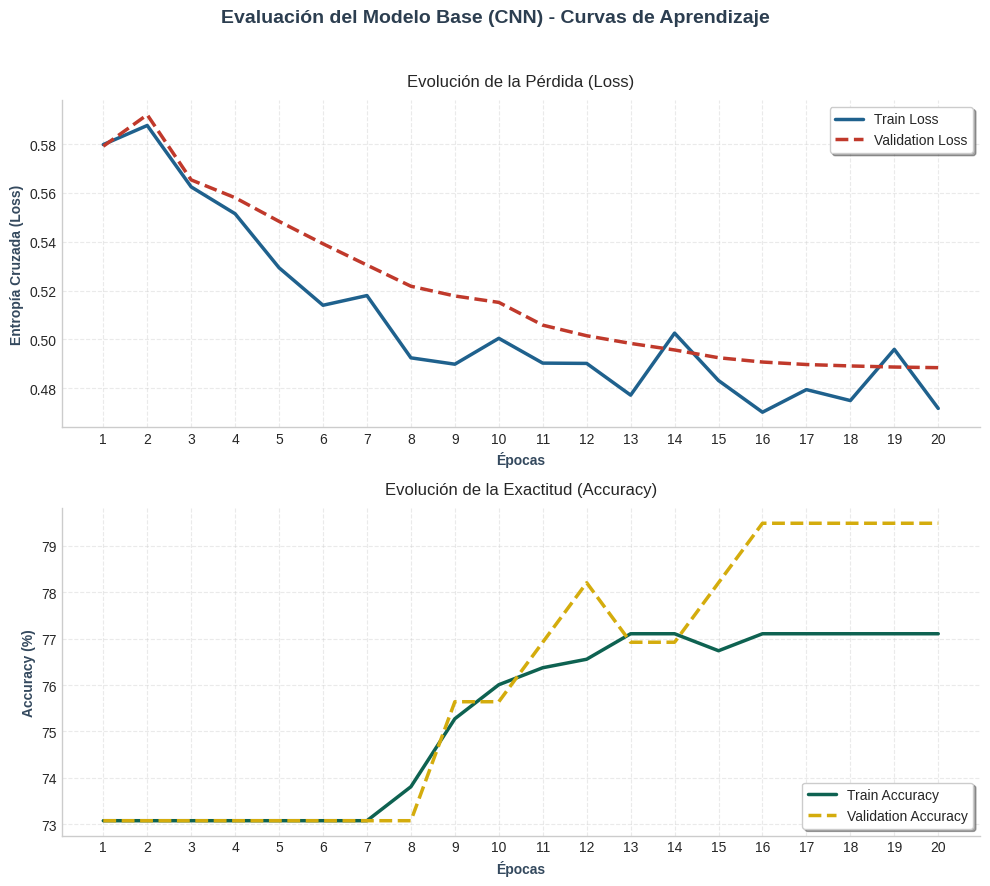

In [91]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history_scratch["train_loss"]) + 1)

train_acc_pct = [a * 100 for a in history_scratch["train_acc"]]
val_acc_pct = [a * 100 for a in history_scratch["val_acc"]]

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Layout vertical (2 filas, 1 columna)
fig, axes = plt.subplots(2, 1, figsize=(10, 9))
fig.patch.set_facecolor('white')

fig.suptitle("Evaluación del Modelo Base (CNN) - Curvas de Aprendizaje",
             fontsize=14, fontweight="bold", y=0.98, color="#2C3E50")

# --- Gráfica 1 (Arriba): Pérdida (Loss) ---
axes[0].plot(epochs_range, history_scratch["train_loss"], label="Train Loss", color="#1F618D", linewidth=2.5)
axes[0].plot(epochs_range, history_scratch["val_loss"], label="Validation Loss", color="#C0392B", linewidth=2.5, linestyle="--")

axes[0].set_title("Evolución de la Pérdida (Loss)", fontsize=12, pad=10)
axes[0].set_xlabel("Épocas", fontsize=10, fontweight="bold", color="#34495E")
axes[0].set_ylabel("Entropía Cruzada (Loss)", fontsize=10, fontweight="bold", color="#34495E")
axes[0].set_xticks(epochs_range)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend(loc="upper right", frameon=True, shadow=True)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Gráfica 2 (Abajo): Exactitud (Accuracy) ---
axes[1].plot(epochs_range, train_acc_pct, label="Train Accuracy", color="#0E6251", linewidth=2.5)
axes[1].plot(epochs_range, val_acc_pct, label="Validation Accuracy", color="#D4AC0D", linewidth=2.5, linestyle="--")

axes[1].set_title("Evolución de la Exactitud (Accuracy)", fontsize=12, pad=10)
axes[1].set_xlabel("Épocas", fontsize=10, fontweight="bold", color="#34495E")
axes[1].set_ylabel("Accuracy (%)", fontsize=10, fontweight="bold", color="#34495E")
axes[1].set_xticks(epochs_range)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend(loc="lower right", frameon=True, shadow=True)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

7.4 **Evaluación final en test La evaluación**

 Debe reportarse en un conjunto no visto (test) para estimar generalización.

In [111]:
target_names = ["Sin Retinopatía (0)", "Con Retinopatía (1)"]
print("Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=target_names))

Reporte de Clasificación:
                     precision    recall  f1-score   support

Sin Retinopatía (0)       0.80      0.19      0.31        42
Con Retinopatía (1)       0.77      0.98      0.86       114

           accuracy                           0.77       156
          macro avg       0.78      0.59      0.58       156
       weighted avg       0.78      0.77      0.71       156



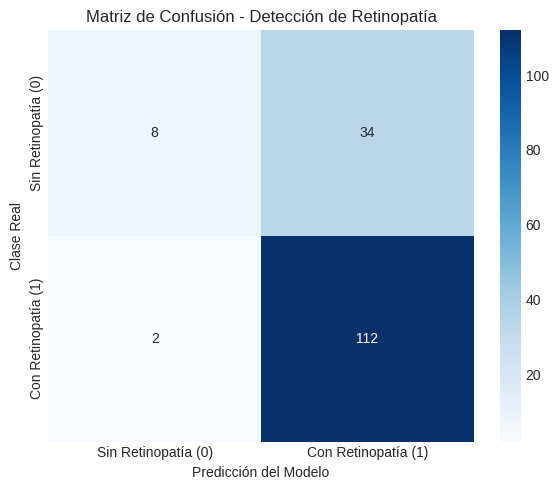

In [110]:
#la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Matriz de Confusión - Detección de Retinopatía")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real")
plt.tight_layout()
plt.show()

8. **Data Augmentation (aumento de datos)
En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado**:

Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.
Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.

In [96]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [100]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_aug.parameters(), lr=5e-4, weight_decay=1e-4)

epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

history_aug = {
    "train_loss": [], "val_loss": [],
    "train_acc": [],  "val_acc": [],
    "diff_loss": [],  "diff_acc": []
}

print(f"{'Época':^7} | {'Train Loss':^10} | {'Val Loss':^10} | {'Dif Loss':^10} | {'Train Acc':^10} | {'Val Acc':^10} | {'Dif Acc':^10}")
print("-" * 85)

for epoch in range(1, epochs + 1):
    model_aug.train()
    for x, y in train_loader_aug:
        x, y = x.to(device), y.to(device).long().view(-1)
        optimizer.zero_grad()
        loss = criterion(model_aug(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_aug.parameters(), max_norm=0.5)
        optimizer.step()

    scheduler.step()

    tr_l = compute_loss(model_aug, train_loader_aug)
    va_l = compute_loss(model_aug, val_loader)
    tr_a, _, _, _, _ = evaluate(model_aug, train_loader_aug)
    va_a, va_auc, _, _, _ = evaluate(model_aug, val_loader)

    diff_l = abs(va_l - tr_l)
    diff_a = abs(tr_a - va_a)

    history_aug["train_loss"].append(tr_l)
    history_aug["val_loss"].append(va_l)
    history_aug["train_acc"].append(tr_a)
    history_aug["val_acc"].append(va_a)
    history_aug["diff_loss"].append(diff_l)
    history_aug["diff_acc"].append(diff_a)

    print(f" {epoch:02d}/{epochs}  |  {tr_l:8.4f}  |  {va_l:8.4f}  |  {diff_l:8.4f}  |{tr_a:8.4f}  |  {va_a:8.4f}  |  {diff_a:8.4f}")

 Época  | Train Loss |  Val Loss  |  Dif Loss  | Train Acc  |  Val Acc   |  Dif Acc  
-------------------------------------------------------------------------------------
 01/20  |    0.5765  |    0.5819  |    0.0054  |  0.7308  |    0.7308  |    0.0000


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 02/20  |    0.6066  |    0.5870  |    0.0196  |  0.7308  |    0.7308  |    0.0000


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 03/20  |    0.5677  |    0.5828  |    0.0151  |  0.7308  |    0.7308  |    0.0000


...

 18/20  |    0.5246  |    0.5398  |    0.0153  |  0.7491  |    0.7436  |    0.0055


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 19/20  |    0.5111  |    0.5393  |    0.0282  |  0.7674  |    0.7436  |    0.0238


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 20/20  |    0.4939  |    0.5390  |    0.0451  |  0.7491  |    0.7436  |    0.0055


8.1. Comparación rápida

In [98]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

Sin augmentation  | test_acc=0.7692 | test_auc=0.7861
Con augmentation  | test_acc=0.7372 | test_auc=0.7112


9. **Transfer Learning en imágenes médicas**

El transfer learning consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:

Converge más rápido.
Suele mejorar rendimiento con pocos datos.
Desafíos en imágenes médicas:

Muchas imágenes médicas son en escala de grises.
El dominio es distinto a fotos naturales.
Aun así, usar redes como ResNet puede ayudar. Aquí haremos:

Convertir la imagen a 3 canales.
Redimensionar a un tamaño típico de ResNet.
Entrenar un clasificador encima.

In [115]:
import torchvision.transforms as T

# Transformaciones para entrenamiento (incluye aumento de datos y adaptación a 3 canales)
transform_tl_train = T.Compose([
    T.Resize((224, 224)),                       # Tamaño de entrada requerido por ResNet18
    T.Grayscale(num_output_channels=3),         # BreastMNIST es de 1 canal; ResNet18 requiere 3 canales
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalización estándar de ImageNet
])

# Transformaciones para validación y prueba (sin aumento de datos)
transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Carga de las particiones usando DataClass definido en tu cuaderno
train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl   = DataClass(split="val",   transform=transform_tl_eval,  download=True)
test_dataset_tl  = DataClass(split="test",  transform=transform_tl_eval,  download=True)

# Asegurar que las etiquetas sean unidimensionales (consistente con el paso 3 de tu cuaderno)
train_dataset_tl.labels = train_dataset_tl.labels.squeeze()
val_dataset_tl.labels   = val_dataset_tl.labels.squeeze()
test_dataset_tl.labels  = test_dataset_tl.labels.squeeze()

# Creación de los DataLoaders de PyTorch para Transfer Learning
train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl   = DataLoader(val_dataset_tl,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl  = DataLoader(test_dataset_tl,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Verificación de la forma del lote (debe salir [64, 3, 224, 224])
print("Forma del lote (Transfer Learning):", next(iter(train_loader_tl))[0].shape)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forma del lote (Transfer Learning): torch.Size([64, 3, 224, 224])


9.1. **Construir el modelo preentrenado (ResNet18)**

In [116]:
import torchvision.models as models

# Cargar el modelo ResNet18 con los pesos preentrenados por defecto
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modificar la capa totalmente conectada (fc) para ajustarla al número de clases (num_classes = 2)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)

# Enviar el modelo al dispositivo configurado en tu cuaderno (device)
resnet = resnet.to(device)

# Congelar todo el backbone al inicio para conservar las características aprendidas
for name, param in resnet.named_parameters():
    param.requires_grad = False

# Habilitar gradientes únicamente para la última capa (el clasificador nuevo)
for param in resnet.fc.parameters():
    param.requires_grad = True

9.2. **Entrenamiento etapa 1**

In [128]:
# Entrenamiento etapa 1

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):

    # ENTRENAMIENTO
    resnet.train()
    losses = []

    for x, y in train_loader_tl:
        x = x.to(device)

        # Convertir las etiquetas originales 0-4 a 0-1
        y = (y.squeeze() > 0).long().to(device)

        optimizer.zero_grad()

        logits = resnet(x)

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    train_loss = float(np.mean(losses))

    # VALIDACIÓN
    resnet.eval()

    val_labels = []
    val_probs = []
    val_preds = []

    with torch.no_grad():

        for x, y in val_loader_tl:
            x = x.to(device)

            # Convertir también las etiquetas de validación a 0-1
            y = (y.squeeze() > 0).long().to(device)

            logits = resnet(x)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs >= 0.5).long()

            val_labels.extend(y.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_preds.extend(preds.cpu().numpy())

    val_labels = np.array(val_labels)
    val_probs = np.array(val_probs)
    val_preds = np.array(val_preds)

    val_acc = accuracy_score(val_labels, val_preds)
    val_auc = roc_auc_score(val_labels, val_probs)

    # GUARDAR HISTORIAL

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=0.5771 | val_acc=0.7250 | val_auc=0.7110


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 02 | train_loss=0.5769 | val_acc=0.6583 | val_auc=0.7107


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 03 | train_loss=0.5592 | val_acc=0.7333 | val_auc=0.7079


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 04 | train_loss=0.5730 | val_acc=0.7083 | val_auc=0.7093


10. **Fine-tuning (descongelar capas)**

In [129]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)

17

In [130]:

optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
# LR más bajo: ya no partimos de cero

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):


    resnet.train()
    losses = []

    for x, y in train_loader_tl:

        x = x.to(device)

        # Convertir etiquetas originales 0-4 a 0-1
        y = (y.squeeze() > 0).long().to(device)

        optimizer.zero_grad()

        logits = resnet(x)

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    train_loss = float(np.mean(losses))


    resnet.eval()

    val_labels = []
    val_probs = []
    val_preds = []

    with torch.no_grad():

        for x, y in val_loader_tl:

            x = x.to(device)

            # Convertir etiquetas originales 0-4 a 0-1
            y = (y.squeeze() > 0).long().to(device)

            logits = resnet(x)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs >= 0.5).long()

            val_labels.extend(y.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_preds.extend(preds.cpu().numpy())

    val_labels = np.array(val_labels)
    val_probs = np.array(val_probs)
    val_preds = np.array(val_preds)

    val_acc = accuracy_score(val_labels, val_preds)
    val_auc = roc_auc_score(val_labels, val_probs)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 01 | train_loss=0.5842 | val_acc=0.7583 | val_auc=0.7652


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 02 | train_loss=0.4963 | val_acc=0.7417 | val_auc=0.8008


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 03 | train_loss=0.4613 | val_acc=0.7417 | val_auc=0.7814


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 04 | train_loss=0.4138 | val_acc=0.7417 | val_auc=0.7719


11. **Evaluación en test del modelo con transfer learning**

In [131]:

test_dataset_tl.labels = (
    test_dataset_tl.labels.squeeze() > 0
).astype(int)

# Usamos la misma función evaluate() de tu cuaderno
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet,
    test_loader_tl
)

print(
    f"Transfer learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        digits=4,
        target_names=["Clase 0", "Clase 1"]
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

cm_tl

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Transfer learning | test_acc=0.7075 | test_auc=0.7419

              precision    recall  f1-score   support

     Clase 0     0.6667    0.6552    0.6609       174
     Clase 1     0.7380    0.7478    0.7429       226

    accuracy                         0.7075       400
   macro avg     0.7023    0.7015    0.7019       400
weighted avg     0.7070    0.7075    0.7072       400



array([[114,  60],
       [ 57, 169]])

12. **Comparación global**

In [132]:
print("Resumen de resultados en test")

print(
    f"CNN desde cero (sin aug)    | "
    f"acc={test_acc:.4f} | auc={test_auc:.4f}"
)

print(
    f"CNN desde cero (con aug)    | "
    f"acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}"
)

print(
    f"Transfer learning (ResNet)  | "
    f"acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}"
)

Resumen de resultados en test
CNN desde cero (sin aug)    | acc=0.7692 | auc=0.7861
CNN desde cero (con aug)    | acc=0.7436 | auc=0.7299
Transfer learning (ResNet)  | acc=0.7075 | auc=0.7419


13. **Interpretabilidad básica: Grad-CAM**

In [133]:
import torch

def grad_cam(model, image_tensor, target_class=None):

    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    # Guardar activaciones de layer4
    def forward_hook(module, inp, out):
        activations["value"] = out

    # Guardar gradientes de layer4
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    # Forward
    logits = model(image_tensor.unsqueeze(0))

    # Clase predicha si no se especifica
    if target_class is None:
        target_class = int(
            torch.argmax(logits, dim=1).item()
        )

    # Backward de la clase seleccionada
    score = logits[0, target_class]

    model.zero_grad()
    score.backward()

    # Obtener activaciones y gradientes
    act = activations["value"][0]
    grad = gradients["value"][0]

    # Pesos de Grad-CAM
    weights = torch.mean(grad, dim=(1, 2))

    # Mapa de activación
    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    # ReLU
    cam = torch.relu(cam)

    # Normalización
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # Eliminar hooks
    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

/tmp/ipykernel_5820/2819689830.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


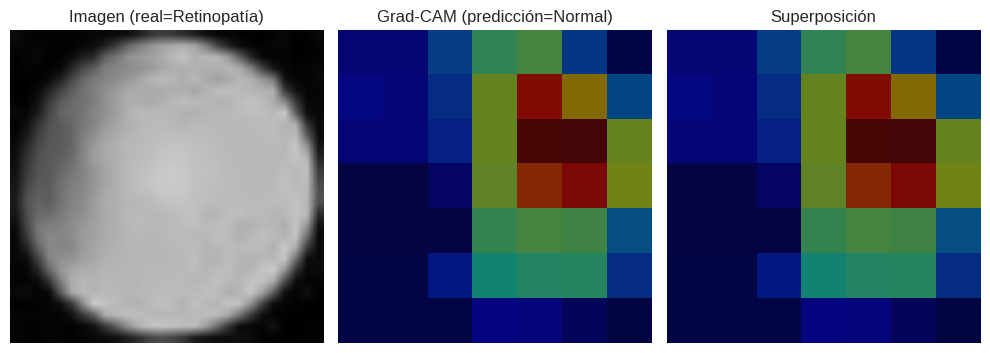

In [134]:
LABELS = {
    0: "Normal",
    1: "Retinopatía"
}

idx = 0  # cambia este índice para ver otras imágenes del test

# Obtener imagen y etiqueta real
x, y = test_dataset_tl[idx]

# Convertir etiqueta a entero
real_class = int(np.asarray(y).squeeze())

# Obtener Grad-CAM y clase predicha
cam, pred_class = grad_cam(resnet, x)

# PREPARAR IMAGEN PARA MOSTRAR

img = x.permute(1, 2, 0).cpu().numpy()

# Desnormalizar según la transformación de tu cuaderno
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img = img * std + mean
img = np.clip(img, 0, 1)

# MOSTRAR RESULTADOS

plt.figure(figsize=(10, 4))

# Imagen original
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (real={LABELS[real_class]})")
plt.axis("off")

# Grad-CAM
plt.subplot(1, 3, 2)
plt.imshow(img)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM (predicción={LABELS[pred_class]})")
plt.axis("off")

# Superposición
plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

código para guardar los 3 modelos entrenados:

In [136]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]

['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

from google.colab import files

files.download("models/cnn_scratch.pth")
files.download("models/cnn_aug.pth")
files.download("models/resnet_transfer.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [137]:
# GUARDAR Y DESCARGAR LOS MODELOS

import os
import torch

# Crear carpeta para los modelos
os.makedirs("models", exist_ok=True)

# Guardar CNN desde cero
torch.save(
    model_scratch.state_dict(),
    "models/cnn_scratch.pth"
)

# Guardar CNN con augmentation
torch.save(
    model_aug.state_dict(),
    "models/cnn_aug.pth"
)

# Guardar ResNet con Transfer Learning
torch.save(
    resnet.state_dict(),
    "models/resnet_transfer.pth"
)

# Mostrar archivos guardados
model_files = [
    "models/cnn_scratch.pth",
    "models/cnn_aug.pth",
    "models/resnet_transfer.pth"
]

print("Modelos guardados correctamente:")

for file in model_files:
    print(file)
# DESCARGAR DESDE GOOGLE COLAB

from google.colab import files

for file in model_files:
    files.download(file)

Modelos guardados correctamente:
models/cnn_scratch.pth
models/cnn_aug.pth
models/resnet_transfer.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
cnn_scratch.pth
cnn_aug.pth
resnet_transfer.pth